<a href="https://colab.research.google.com/github/AdityaJare/ML-PRojects/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**House Price Prediction**


#Load Data

In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [68]:
df = pd.read_csv('/content/sample_data/housing.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


# Data Preprocessing

In [69]:
df.shape

(20640, 10)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [71]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [72]:
df.duplicated().sum()

np.int64(0)

In [73]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


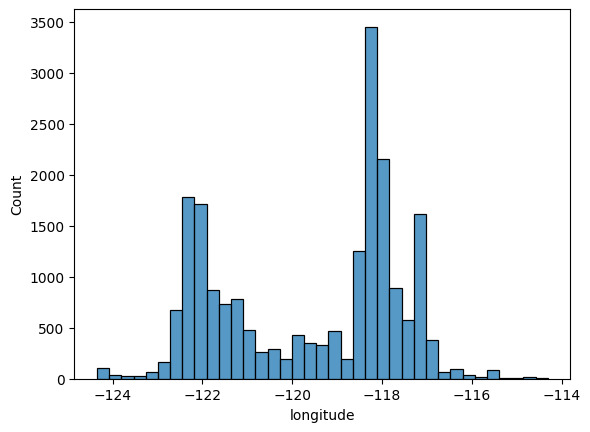

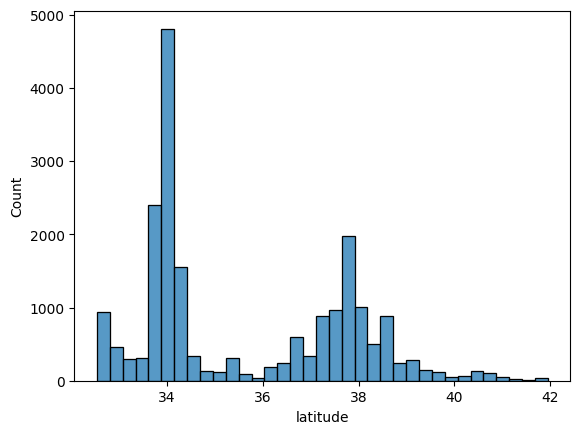

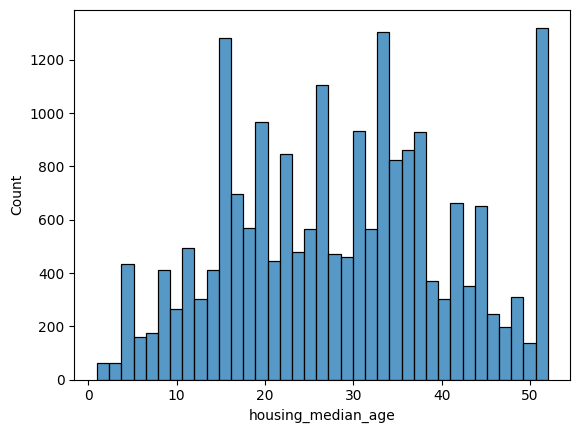

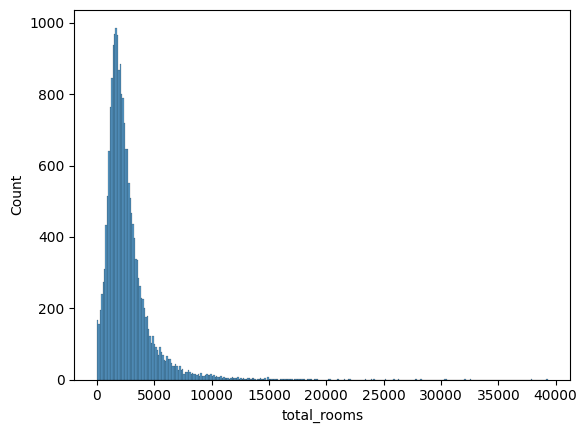

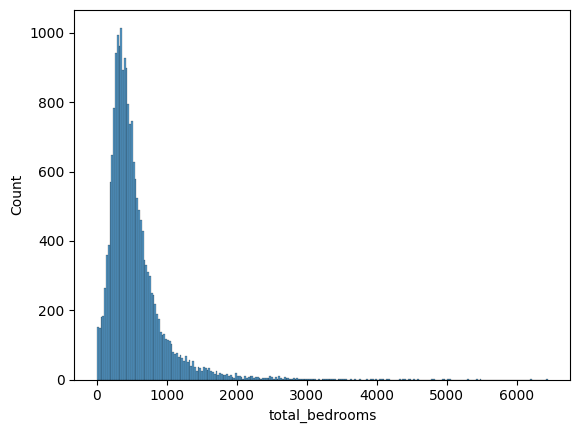

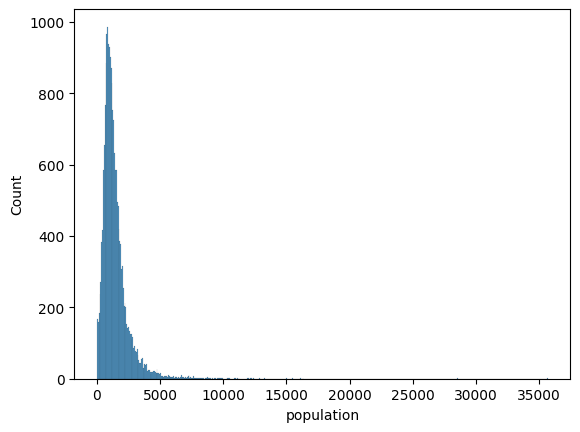

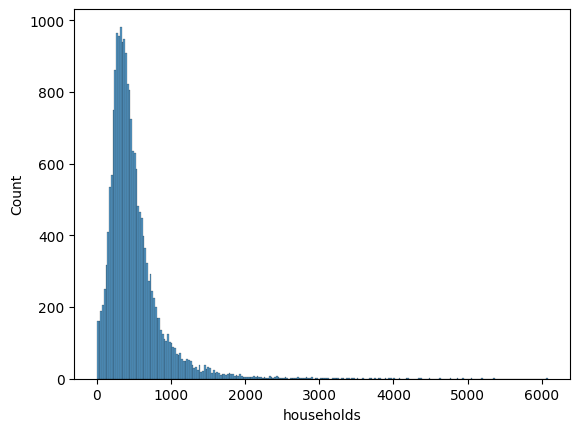

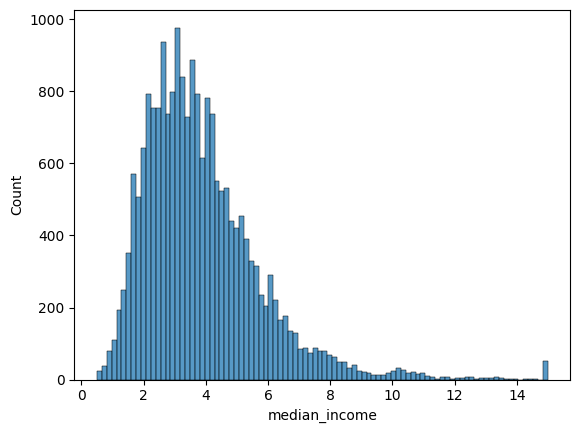

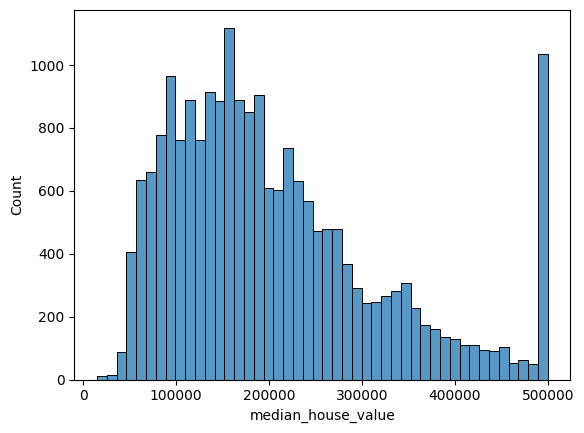

In [74]:
for i in df.select_dtypes(include= "number").columns:
  sns.histplot(data = df, x= i)
  plt.show()

In [75]:
df.select_dtypes(include = "number").columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

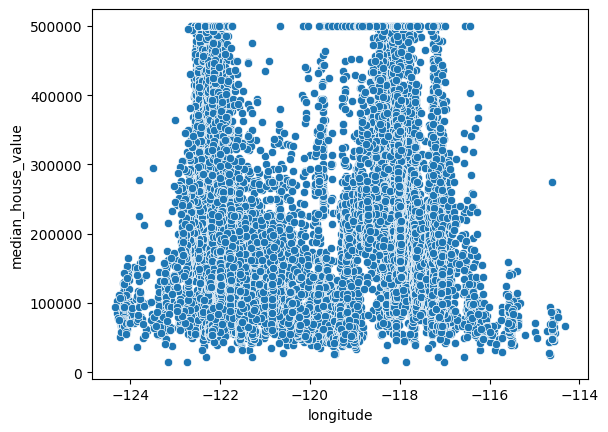

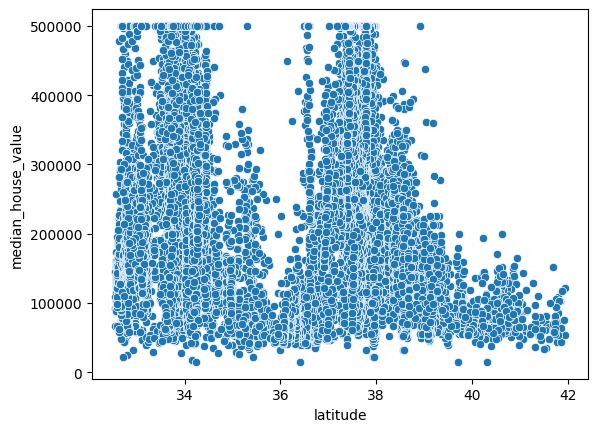

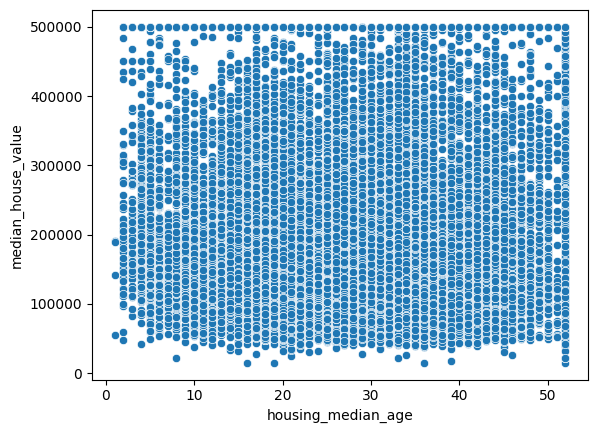

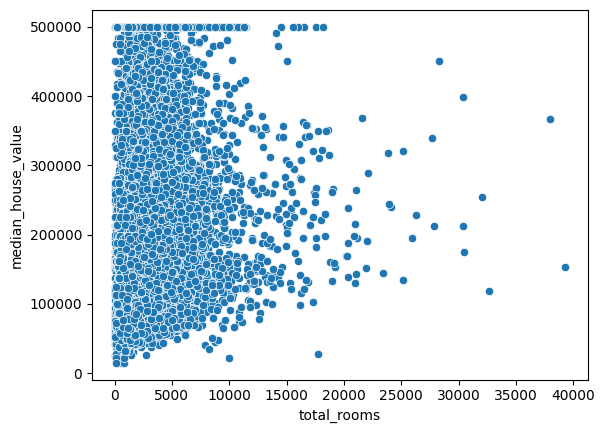

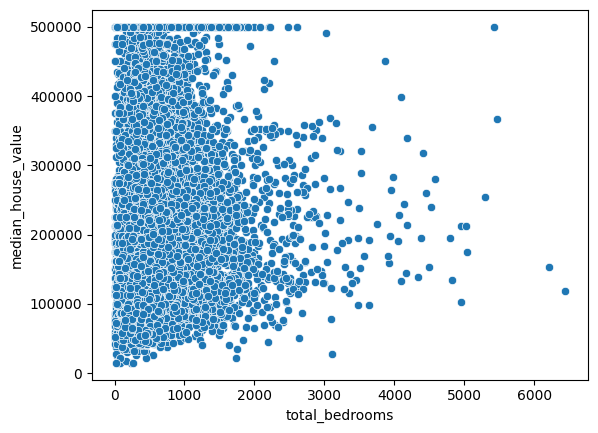

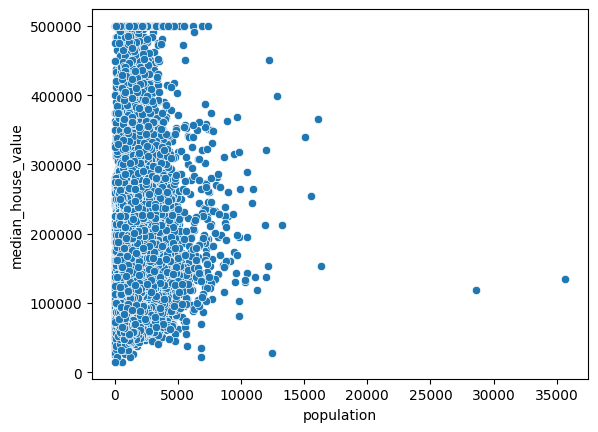

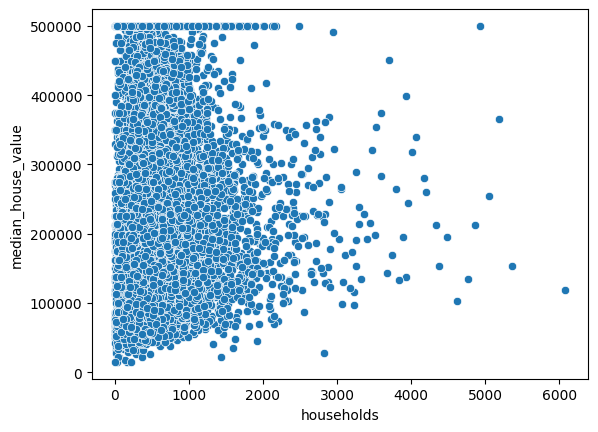

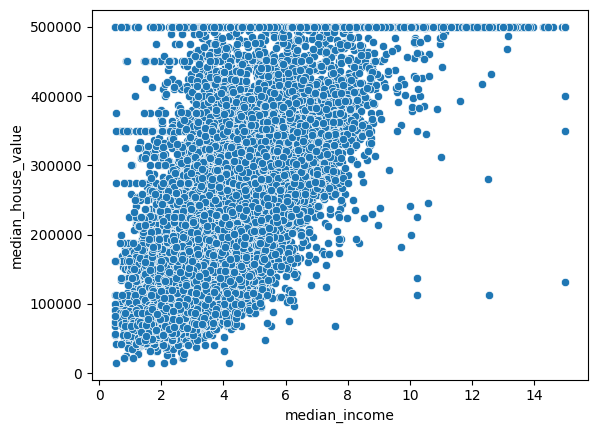

In [76]:
for i in ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income']:
       sns.scatterplot(data = df, x = i, y= 'median_house_value')
       plt.show()


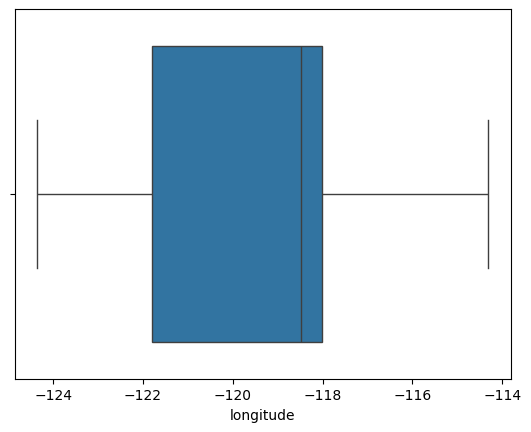

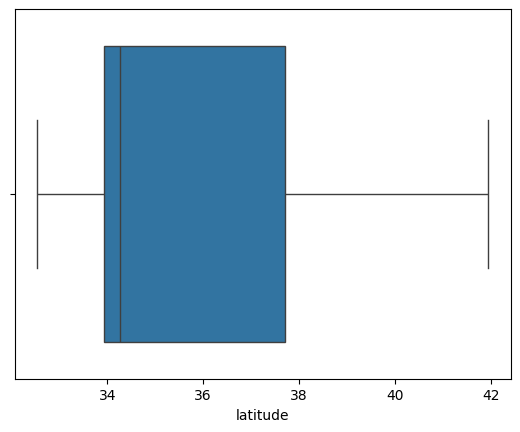

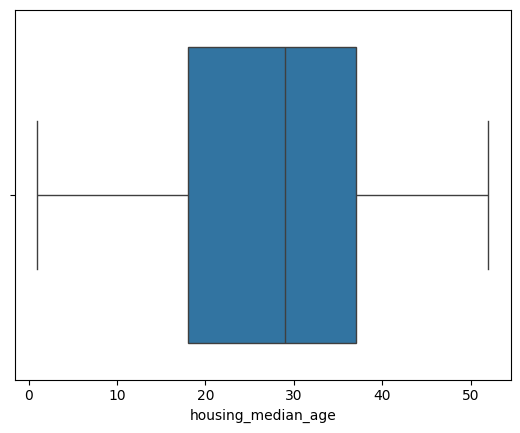

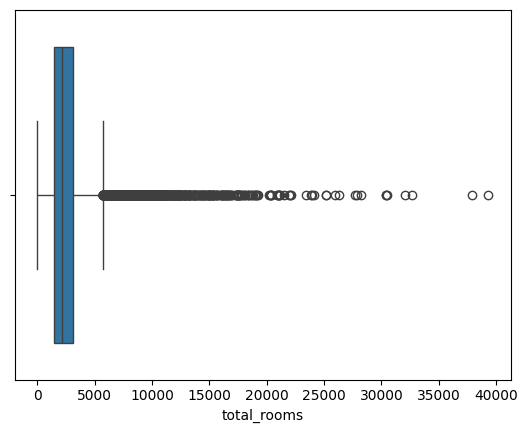

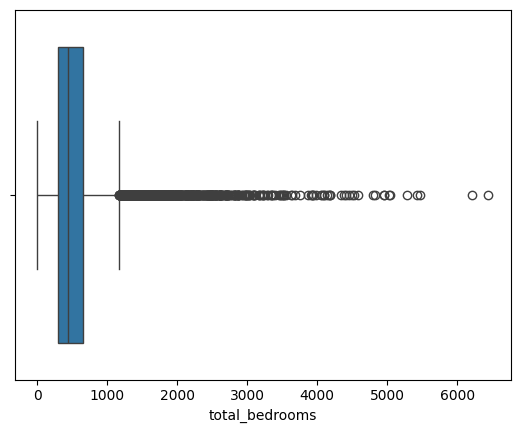

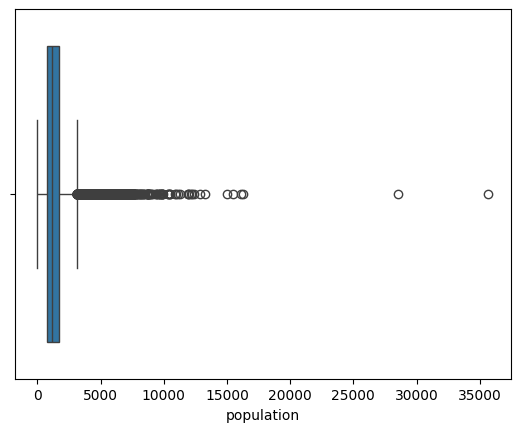

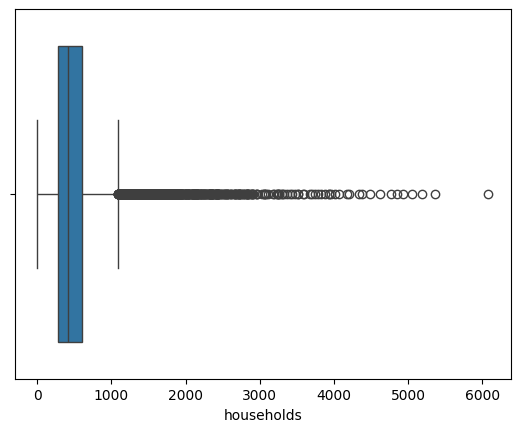

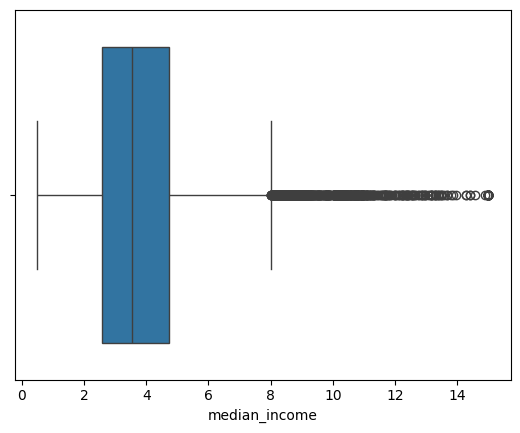

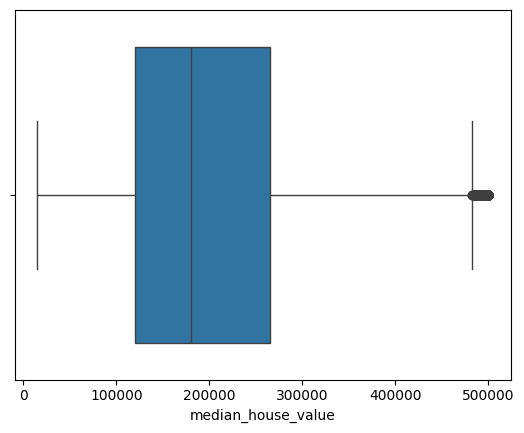

In [77]:
for i in df.select_dtypes(include= "number").columns:
  sns.boxplot(data = df, x= i)
  plt.show()

<Axes: >

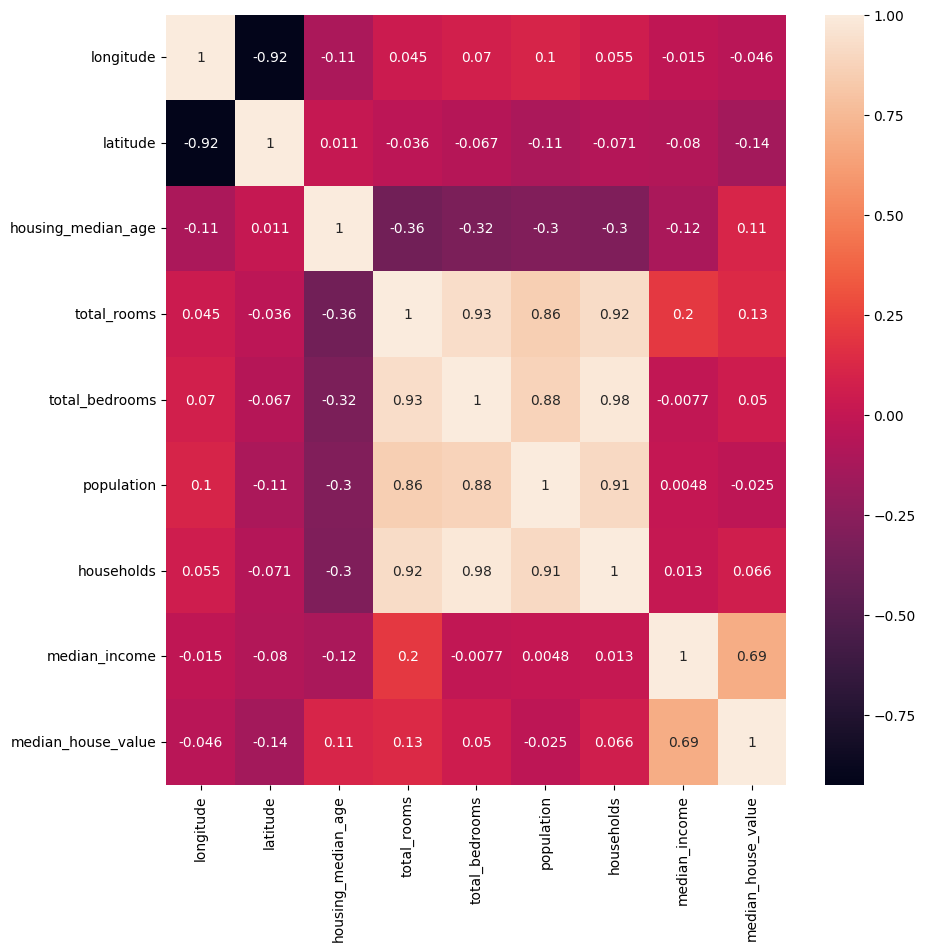

In [78]:
s = df.select_dtypes(include = "number").corr()
plt.figure(figsize = (10, 10))
sns.heatmap(s, annot=True)

In [79]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

In [80]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [81]:
df =df.drop("ocean_proximity", axis=1)

In [82]:
def wisker(col):
  q1, q3=np.percentile(col, [25, 75])
  iqr = q3-q1
  lw = q1 - 1.5*iqr
  uw = q3 + 1.5*iqr
  return lw, uw

In [83]:
for i in ['households', 'total_bedrooms', 'population', 'total_rooms']:
  lw, uw = wisker(df[i])
  df[i] = np.where(df[i]<lw, lw, df[i])
  df[i] = np.where(df[i]>uw, uw, df[i])

In [84]:
df.drop_duplicates()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.000,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,5698.375,1106.0,2401.0,1092.5,8.3014,358500.0
2,-122.24,37.85,52.0,1467.000,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.000,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.000,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.000,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.000,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.000,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.000,409.0,741.0,349.0,1.8672,84700.0


In [85]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedroom_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

In [86]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedroom_per_room,population_per_household
0,-122.23,37.88,41.0,880.000,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,5698.375,1106.0,2401.0,1092.5,8.3014,358500.0,5.215904,0.194090,2.197712
2,-122.24,37.85,52.0,1467.000,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.000,235.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.000,280.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,2.181467
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.000,374.0,845.0,330.0,1.5603,78100.0,5.045455,0.224625,2.560606
20636,-121.21,39.49,18.0,697.000,150.0,356.0,114.0,2.5568,77100.0,6.114035,0.215208,3.122807
20637,-121.22,39.43,17.0,2254.000,485.0,1007.0,433.0,1.7000,92300.0,5.205543,0.215173,2.325635
20638,-121.32,39.43,18.0,1860.000,409.0,741.0,349.0,1.8672,84700.0,5.329513,0.219892,2.123209


# **Data Preparation**

## spliting Data to x and y

In [87]:
x = df.drop("median_house_value", axis=1)
x

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedroom_per_room,population_per_household
0,-122.23,37.88,41.0,880.000,129.0,322.0,126.0,8.3252,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,5698.375,1106.0,2401.0,1092.5,8.3014,5.215904,0.194090,2.197712
2,-122.24,37.85,52.0,1467.000,190.0,496.0,177.0,7.2574,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.000,235.0,558.0,219.0,5.6431,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.000,280.0,565.0,259.0,3.8462,6.281853,0.172096,2.181467
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.000,374.0,845.0,330.0,1.5603,5.045455,0.224625,2.560606
20636,-121.21,39.49,18.0,697.000,150.0,356.0,114.0,2.5568,6.114035,0.215208,3.122807
20637,-121.22,39.43,17.0,2254.000,485.0,1007.0,433.0,1.7000,5.205543,0.215173,2.325635
20638,-121.32,39.43,18.0,1860.000,409.0,741.0,349.0,1.8672,5.329513,0.219892,2.123209


In [88]:
y = df['median_house_value']
y

,median_house_value
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0
...,...
20635,78100.0
20636,77100.0
20637,92300.0
20638,84700.0


## Train test Split

In [89]:
from sklearn.model_selection import train_test_split

x_train0, x_test0, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=100)

In [90]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train0)
x_test = scaler.transform(x_test0)


In [91]:
x_train

array([[-1.55444193,  1.63677864, -1.24008206, ...,  1.31305718,
        -0.08104767,  0.07755024],
       [-0.62304675, -0.14864428, -1.39861471, ..., -0.19187471,
         0.02779188, -0.04506319],
       [-1.36019374,  2.2677527 , -0.84375045, ...,  0.13081668,
        -0.55818558, -0.09618624],
       ...,
       [ 1.17997494, -0.77961835, -2.03274529, ..., -0.07297901,
        -0.15377205, -0.02442771],
       [ 1.24472434, -1.35450583,  0.50377704, ...,  0.36925606,
        -0.58827596,  0.05157046],
       [ 0.63707615, -0.88244375,  1.53423923, ..., -0.09904275,
        -0.2622099 , -0.02047716]])

In [92]:
x_test

array([[ 0.7366906 , -0.85440046,  0.58304336, ...,  0.36405029,
        -0.75851696, -0.08691685],
       [-1.34027085,  1.01982621,  1.85130452, ..., -0.54295099,
         1.03848324, -0.01776964],
       [ 0.22865687, -0.12527487, -1.24008206, ...,  0.55757915,
        -0.88631358,  0.03959866],
       ...,
       [ 1.60333639, -0.8684221 , -1.79494632, ..., -0.07297901,
        -0.15377205, -0.02442771],
       [-0.63300819,  0.87026199,  1.85130452, ..., -0.18085548,
        -0.15142822, -0.06233747],
       [ 1.07537976, -0.79363999,  0.50377704, ..., -0.16308313,
        -0.46530206,  0.0160868 ]])

# Model building

## Linear Regression

### Model training

In [93]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [94]:
y_lr_train_pred =lr.predict(x_train)
y_lr_test_pred = lr.predict(x_test)

In [95]:
y_lr_train_pred

array([149872.78567874, 236919.91367348, 100057.80308641, ...,
       231208.03128997, 155842.25098723, 278604.73813827])

In [96]:
y_lr_test_pred

array([215834.28151475, 155889.5398942 , 196141.17898533, ...,
       115990.20747911, 120748.78200795, 189584.42418685])

### Evaluate model Performance

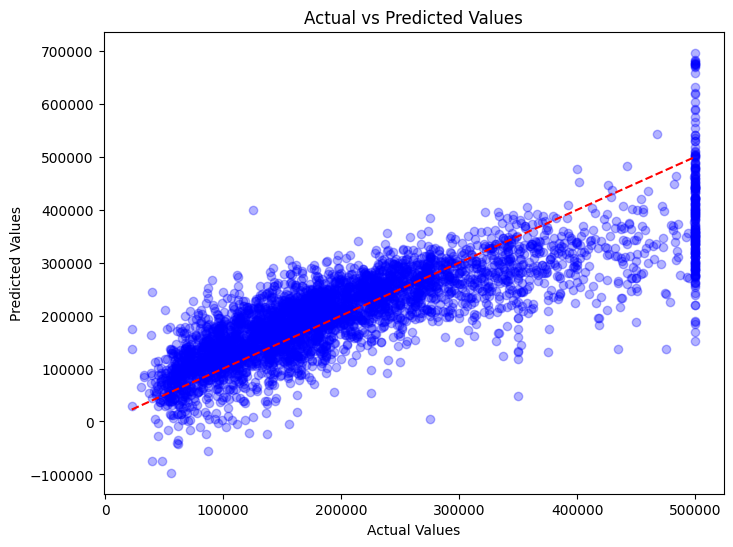

In [97]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_lr_test_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

In [98]:
from sklearn.metrics import mean_squared_error, r2_score

lr_train_MSE = mean_squared_error(y_train, y_lr_train_pred)
lr_train_r2 = r2_score(y_train, y_lr_train_pred)
lr_test_MSE = mean_squared_error(y_test, y_lr_test_pred)
lr_test_r2 = r2_score(y_test, y_lr_test_pred)

In [99]:
print("Mean square error (train) : ", lr_train_MSE )
print("Mean square error (test) : ", lr_test_MSE)
print("R2 score (train) : ", lr_train_r2)
print("R2 score (test) : ", lr_test_r2)

Mean square error (train) :  4621334683.133059
Mean square error (test) :  4373026272.46681
R2 score (train) :  0.651888289262757
R2 score (test) :  0.6754464021322854


In [100]:
lr_result = pd.DataFrame(["Linear Regression", lr_train_MSE, lr_test_MSE, lr_train_r2, lr_test_r2]).transpose()
lr_result.columns = ['Methods', 'Training MSE', 'Test MSE', 'Training R2', 'Test R2']
lr_result

,Methods,Training MSE,Test MSE,Training R2,Test R2
0,Linear Regression,4621334683.133059,4373026272.46681,0.651888,0.675446


## Random Forest

### Model Training

In [101]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=40,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)

RandomForestRegressor(max_depth=40, max_features='sqrt', min_samples_leaf=4,
                      min_samples_split=10, n_estimators=1000, n_jobs=-1,
                      random_state=42)

In [102]:
y_rf_train_pred = rf.predict(x_train)
y_rf_test_pred = rf.predict(x_test)

### Evaluate model performance

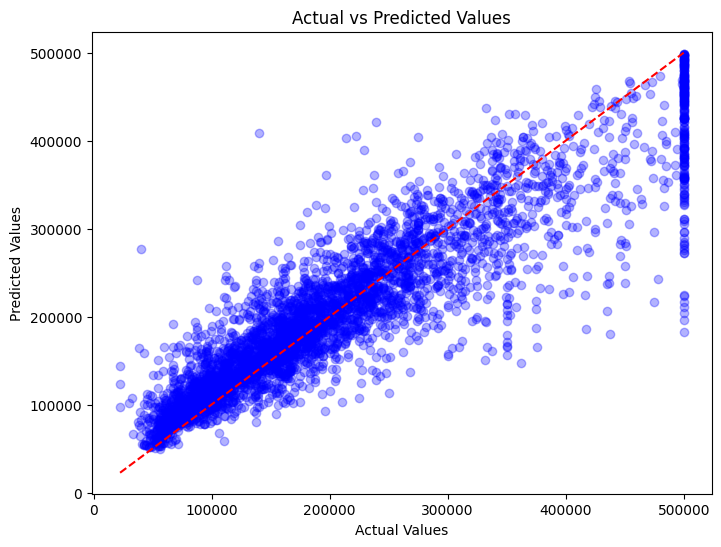

In [103]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_rf_test_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

In [104]:
from sklearn.metrics import mean_squared_error, r2_score

rf_train_MSE = mean_squared_error(y_train, y_rf_train_pred)
rf_train_r2 = r2_score(y_train, y_rf_train_pred)
rf_test_MSE = mean_squared_error(y_test, y_rf_test_pred)
rf_test_r2 = r2_score(y_test, y_rf_test_pred)

In [105]:
print("Mean square error (train) : ", rf_train_MSE )
print("Mean square error (test) : ", rf_test_MSE)
print("R2 score (train) : ", rf_train_r2)
print("R2 score (test) : ", rf_test_r2)

Mean square error (train) :  1321202248.0919075
Mean square error (test) :  2537735582.4392133
R2 score (train) :  0.9004776744493744
R2 score (test) :  0.8116564679925969


In [106]:
rf_result = pd.DataFrame([" Random Forest", rf_train_MSE, rf_test_MSE, rf_train_r2, rf_test_r2]).transpose()
rf_result.columns = ['Methods', 'Training MSE', 'Test MSE', 'Training R2', 'Test R2']
rf_result

,Methods,Training MSE,Test MSE,Training R2,Test R2
0,Random Forest,1321202248.091908,2537735582.439213,0.900478,0.811656


In [107]:
df_models = pd.concat([lr_result, rf_result], axis=0)
df_models

,Methods,Training MSE,Test MSE,Training R2,Test R2
0,Linear Regression,4621334683.133059,4373026272.46681,0.651888,0.675446
0,Random Forest,1321202248.091908,2537735582.439213,0.900478,0.811656


## Lasso Regression

### Model Training

In [108]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(alphas= [0.01, 0.1, 1, 10, 100], cv=5)
lasso_cv.fit(x_train, y_train)

LassoCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)

In [109]:
print("Best alpha:", lasso_cv.alpha_)
print("Best score (R²):", lasso_cv.score(x_test, y_test))

Best alpha: 100.0
Best score (R²): 0.6749897722781115


In [110]:
y_lasso_cv_train_pred = lasso_cv.predict(x_train)
y_lasso_cv_test_pred = lasso_cv.predict(x_test)

### Evaluate Model Performance

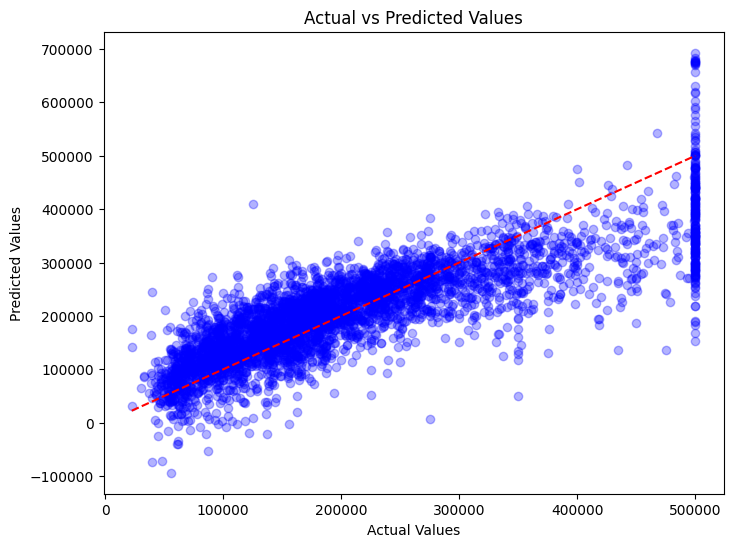

In [111]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_lasso_cv_test_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

In [112]:
from sklearn.metrics import mean_squared_error, r2_score

lasso_cv_train_MSE = mean_squared_error(y_train, y_lasso_cv_train_pred)
lasso_cv_train_r2 = r2_score(y_train, y_lasso_cv_train_pred)
lasso_cv_test_MSE = mean_squared_error(y_test, y_lasso_cv_test_pred)
lasso_cv_test_r2 = r2_score(y_test, y_lasso_cv_test_pred)

In [113]:
lasso_cv_result = pd.DataFrame(["LassoCV Regresion", lasso_cv_train_MSE, lasso_cv_test_MSE, lasso_cv_train_r2, lasso_cv_test_r2]).transpose()
lasso_cv_result.columns = ['Methods', 'Training MSE', 'Test MSE', 'Training R2', 'Test R2']
lasso_cv_result

,Methods,Training MSE,Test MSE,Training R2,Test R2
0,LassoCV Regresion,4622385079.037026,4379178890.592796,0.651809,0.67499


In [114]:
data_model = pd.concat([lr_result, rf_result, lasso_cv_result], axis=0)

In [115]:
data_model

,Methods,Training MSE,Test MSE,Training R2,Test R2
0,Linear Regression,4621334683.133059,4373026272.46681,0.651888,0.675446
0,Random Forest,1321202248.091908,2537735582.439213,0.900478,0.811656
0,LassoCV Regresion,4622385079.037026,4379178890.592796,0.651809,0.67499


## Gradient **Boosting**

### Model Training

In [116]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=1000,
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=42
)

gbr.fit(x_train, y_train)

GradientBoostingRegressor(max_depth=4, max_features='sqrt', min_samples_leaf=3,
                          min_samples_split=5, n_estimators=1000,
                          random_state=42)

In [117]:
y_gbr_train_pred = gbr.predict(x_train)
y_gbr_test_pred = gbr.predict(x_test)

### Evaluate Model Performance

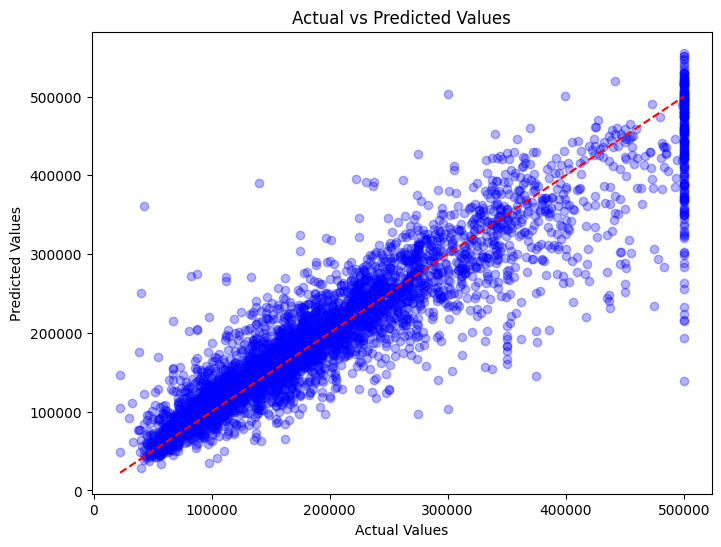

In [118]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_gbr_test_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

In [119]:
from sklearn.metrics import mean_squared_error, r2_score

gbr_train_MSE = mean_squared_error(y_train, y_gbr_train_pred)
gbr_train_r2 = r2_score(y_train, y_gbr_train_pred)
gbr_test_MSE = mean_squared_error(y_test, y_gbr_test_pred)
gbr_test_r2 = r2_score(y_test, y_gbr_test_pred)

In [120]:
print("Mean square error (train) : ", gbr_train_MSE )
print("Mean square error (test) : ", gbr_test_MSE)
print("R2 score (train) : ", gbr_train_r2)
print("R2 score (test) : ", gbr_test_r2)

Mean square error (train) :  951637321.1266689
Mean square error (test) :  2057075922.6080668
R2 score (train) :  0.9283159263344629
R2 score (test) :  0.8473296636763886


In [121]:
gbr_result = pd.DataFrame(["Gradient Boosting Regressor", gbr_train_MSE, gbr_test_MSE, gbr_train_r2, gbr_test_r2]).transpose()
gbr_result.columns = ['Methods', 'Training MSE', 'Test MSE', 'Training R2', 'Test R2']
gbr_result

,Methods,Training MSE,Test MSE,Training R2,Test R2
0,Gradient Boosting Regressor,951637321.126669,2057075922.608067,0.928316,0.84733


In [122]:
data_model = pd.concat([lr_result, rf_result, lasso_cv_result, gbr_result], axis=0)

In [123]:
data_model

,Methods,Training MSE,Test MSE,Training R2,Test R2
0,Linear Regression,4621334683.133059,4373026272.46681,0.651888,0.675446
0,Random Forest,1321202248.091908,2537735582.439213,0.900478,0.811656
0,LassoCV Regresion,4622385079.037026,4379178890.592796,0.651809,0.67499
0,Gradient Boosting Regressor,951637321.126669,2057075922.608067,0.928316,0.84733
